## Awari ML - Atividade 2
- Construção desse notebook, passo a passo: https://www.loom.com/share/243bc6e99e3347d99138f0f2d96559e8

- Continuação do vídeo: https://www.loom.com/share/1108a1a19a6d432f921f2bcfa86ce865

In [1]:
# Todas as importações
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Todos os parâmetros
TRAIN_PATH = '/kaggle/input/titanic/train.csv'
TEST_PATH = '/kaggle/input/titanic/test.csv'
GENDER_SUBM = '/kaggle/input/titanic/gender_submission.csv'

In [3]:
# Funcoes e classes

In [4]:
# Execucao
train = pd.read_csv(TRAIN_PATH)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Variavel idade contem valores ausentes, Cabin e Embarked tambem. Todos deverao sem tratados
# 891 passageiros para treinamento
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test = pd.read_csv(TEST_PATH)
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
# Teste nao contem a variavel survived pois sera o que vamos prever.
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [8]:
test.PassengerId

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [9]:
# Este sera o arquivo a ser submetido. Temos acima o conjunto de testes com varios IDS,
# e para submissao no Kaggle devemos colocar o id de cada um e se o mesmo sobreviveu ou nao.
submission = pd.read_csv(GENDER_SUBM)
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Criando um modelo baseline

In [10]:
# Primeiramente vamos tratar os dados de entrada
# Algumas variaveis parecem muito "sujas" para serem alimentadas já de inicio
# Fica como exercicio descobrir se faz sentido alimentar PassengerId e Name ou nao


NUM_COLS = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
CAT_COLS = ['Sex', 'Cabin', 'Embarked', 'Ticket']
TARGET_COL = 'Survived'
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


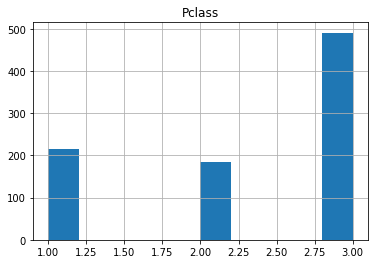

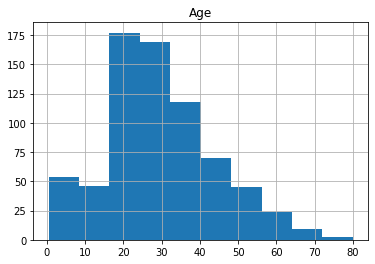

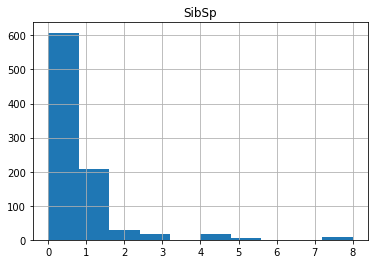

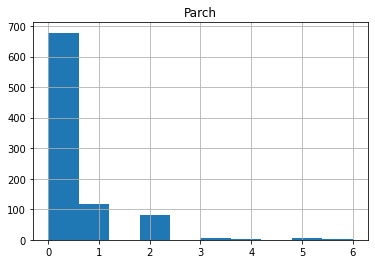

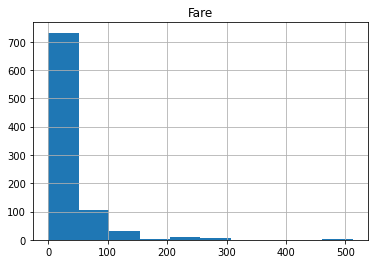

In [11]:
# Investigando a distribuicao das variaveis numericas
for col in NUM_COLS:
    train[col].hist()
    plt.title(col)
    plt.show()
    

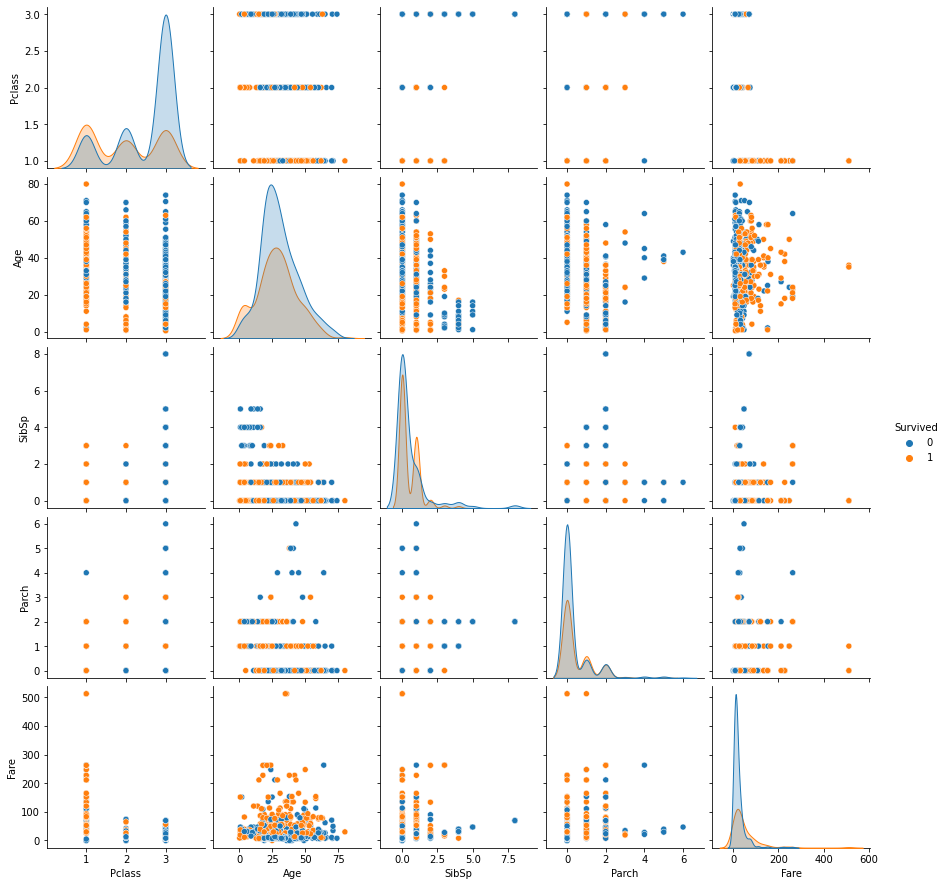

In [12]:
sns.pairplot(train[NUM_COLS + [TARGET_COL]], hue=TARGET_COL)

<AxesSubplot:>

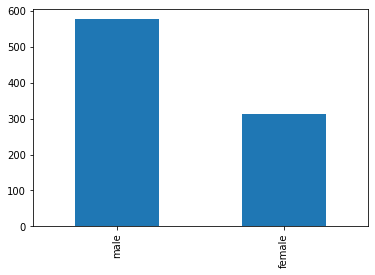

In [13]:
# Investigando a distribuicao das variaveis categoricas
# Exemplo
col = CAT_COLS[0]
train[col].value_counts().plot.bar()

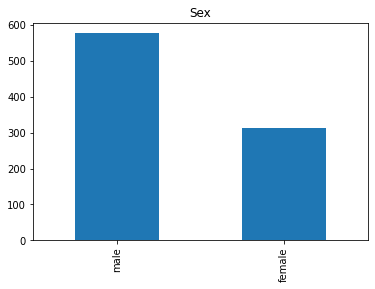

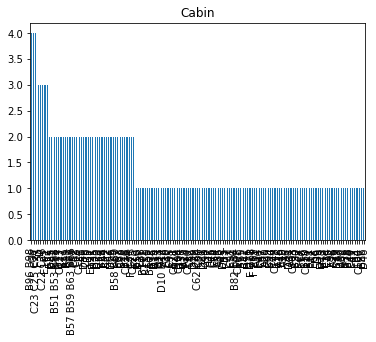

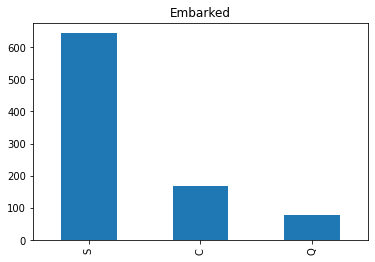

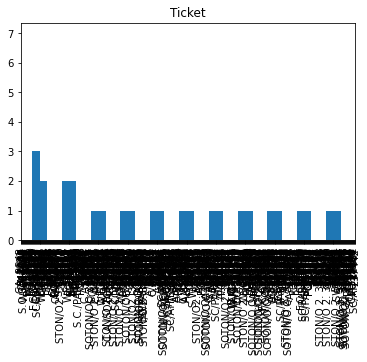

In [14]:
for col in CAT_COLS:
    train[col].value_counts().plot.bar()
    plt.title(col)
    plt.show()

In [15]:
# Cabin contém muitos valores distintos, não introduz informações que poderiam ser correlacionadas com o resto dos dados
# Atributos para considerarmos para engenharia de atributos: Name, Cabin, Ticket

CAT_COLS.remove('Ticket')

In [16]:
# Deixando explicito que removi posteriormente apos conferir os graficos de distribuicao
CAT_COLS.remove('Cabin')

In [17]:
# Tratamento de valores numericos ausentes
# Um bom ponto de partida é imputar com a mediana
train[NUM_COLS].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     714 non-null    float64
 2   SibSp   891 non-null    int64  
 3   Parch   891 non-null    int64  
 4   Fare    891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [18]:
# Aqui, ambos treino e teste sao atualizados com dados do conjunto de treino, pois em um ambiente real, 
# não temos acesso aos dados de teste (simulando dados de producao)

train_med = train[NUM_COLS].median()
train[NUM_COLS]=train[NUM_COLS].fillna(train_med)
test[NUM_COLS]=test[NUM_COLS].fillna(train_med)

In [19]:
train[NUM_COLS].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     891 non-null    float64
 2   SibSp   891 non-null    int64  
 3   Parch   891 non-null    int64  
 4   Fare    891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [20]:
# Uma sugestao para inputar valores ausentes em dados categoricos é usar get_dummies
# O mesmo substituira por 0 em todas as colunas de um valor ausente
# Outra alternativa seria preencher com o valor mais frequente
train[CAT_COLS].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sex       891 non-null    object
 1   Embarked  889 non-null    object
dtypes: object(2)
memory usage: 14.0+ KB


In [21]:
train_cat_dummy = pd.get_dummies(train[CAT_COLS])
train_cat_dummy

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1
1,1,0,1,0,0
2,1,0,0,0,1
3,1,0,0,0,1
4,0,1,0,0,1
...,...,...,...,...,...
886,0,1,0,0,1
887,1,0,0,0,1
888,1,0,0,0,1
889,0,1,1,0,0


In [22]:
# Por exemplo, se sexo estivesse ausente, ficaria 0 0
test_cat_dummy = pd.get_dummies(test[CAT_COLS])
test_cat_dummy

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,1,0
1,1,0,0,0,1
2,0,1,0,1,0
3,0,1,0,0,1
4,1,0,0,0,1
...,...,...,...,...,...
413,0,1,0,0,1
414,1,0,1,0,0
415,0,1,0,0,1
416,0,1,0,0,1


### Divisão X e y Treinamento e X/y Teste

In [23]:
from sklearn.model_selection import train_test_split

# Agora todos os dados de entrada sao numericos
X = pd.concat([train[NUM_COLS], train_cat_dummy], axis=1)
y = train[TARGET_COL]

In [24]:
# posteriormente podemos usar validacao cruzada, por simplicidade aqui vamos usar
# train_test_split para criar o conjunto de validacao
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

In [25]:
X_test = pd.concat([test[NUM_COLS], test_cat_dummy], axis=1)
display(X_test.head())

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,0,1,0,1,0
1,3,47.0,1,0,7.0000,1,0,0,0,1
2,2,62.0,0,0,9.6875,0,1,0,1,0
3,3,27.0,0,0,8.6625,0,1,0,0,1
4,3,22.0,1,1,12.2875,1,0,0,0,1


In [26]:
# Vamos iniciar a triagem com regressao logistica
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression()

In [27]:
lr.score(X_train, y_train) # Score padrao em classificadores eh a acuracia

0.7994011976047904

In [28]:
lr.score(X_val, y_val)

0.8026905829596412

In [29]:
# Conjunto de validacao melhor que de treino eh um sinal de overfitting, vamos testar RandomForest

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf.score(X_train, y_train)

0.9805389221556886

In [32]:
rf.score(X_val, y_val)

0.7937219730941704

In [33]:
# Temos um exemplo de overfitting com random forest. 
# Score de treino quase perfeito e de teste menor que de LR

In [34]:
from xgboost import XGBClassifier

In [35]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
xgb.score(X_train, y_train)

[19:59:22] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/xgboost/data.py:114: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  "because it will generate extra copies and increase " +


0.968562874251497

In [36]:
xgb.score(X_val, y_val)

/opt/conda/lib/python3.7/site-packages/xgboost/data.py:114: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  "because it will generate extra copies and increase " +


0.7847533632286996

In [37]:
# Até o momento LR tem se saido melhor, vamos testar submeter ele

In [38]:
# Survived é um valor aleatorio no momento, vamos substituir pelo survived que 
# prevemos com regressao logistica
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [39]:
submission['Survived']=lr.predict(X_test)

In [40]:
submission.to_csv('submission.csv', index=False)

In [41]:
pd.read_csv('submission.csv')

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


Score no conjunto de teste: 0.76. A partir daqui várias coisas podem ser melhoradas:
- Utilizar validação cruzada, desta forma, aproveitando todo o conjunto de treino
- Calibração dos modelos para lidar com overfitting/underfitting
- Fazer engenharia de atributos para aproveitamento dos outros atributos
- Outros metodos para inputar valores ausentes, por exemplo, treinar um regressor para prever a idade de um passageiro a partir dos outros atributos. 
- Confiram tambem os outros notebooks, estratégias como stacking de vários modelos podem ser ignoradas por hora, tentem chegar à um melhor resultado usando um único modelo (ou combinação do mesmo)
